In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import datetime as dt 
import astropy 
import pytz 
import src 
import pandas as pd 
import astroplan 



c:\Users\johnm\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\Users\johnm\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [40]:
# Important camera properties 

# Color camera: 
# Fov: 42' x 27.6' 
# Plate scale: 0.41" / pixel 

# Monochrome camera: 
# Fov: 32' x 21.5' 
# Plate scale: 0.63" / pixel 




# print parameters of movement of a source across the sky 
def func(pixels_per_hour=None, time_cross_FOV=None, arcsec_per_hour=None, arcsec_per_pixel=0.63, FOV_arcmin=42): 

    FOV_arcsec = FOV_arcmin*60 

    if time_cross_FOV is not None: 
        arcsec_per_hour = FOV_arcsec / time_cross_FOV
        pixels_per_hour = arcsec_per_hour / arcsec_per_pixel 
    
    if pixels_per_hour is not None: 
        arcsec_per_hour = pixels_per_hour * arcsec_per_pixel 
        time_cross_FOV = FOV_arcsec / arcsec_per_hour 

    if arcsec_per_hour is not None: 
        pixels_per_hour = arcsec_per_hour / arcsec_per_pixel 
        time_cross_FOV = FOV_arcsec / arcsec_per_hour 


    print(f"Pixels per hour: {pixels_per_hour} pix")
    print(f'Arcsec per hour: {arcsec_per_hour}"') 
    print(f"Time to cross camera: {time_cross_FOV} hours ({time_cross_FOV*60:.0f} mins)") 
    print(f"\n") 



print("Minimum speed to detect in single night")
func(pixels_per_hour=10)

print("Maximum speed (moves out of frame in less than an hour)")
func(time_cross_FOV=1) 


Minimum speed to detect in single night
Pixels per hour: 10.0 pix
Arcsec per hour: 6.3"
Time to cross camera: 400.0 hours (24000 mins)


Maximum speed (moves out of frame in less than an hour)
Pixels per hour: 4000.0 pix
Arcsec per hour: 2520.0"
Time to cross camera: 1.0 hours (60 mins)




Comets and asteroids target list (spring-summer 2026) 

| Name               | Date Observable        | Speed (arcsec/hr) | Magnitude |
|--------------------|------------------------|-------------------|-----------|
| 20 Massalia        | until July 23          | 3–60              | 9.3–11.5  |
| 7 Iris             | until July 23          | 1–54              | 9.7–11.4  |
| 19 Fortuna         | until July 23          | 2–43              | 11.5–13.2 |
| 41 Daphne          | until July 23          | 2–67              | 11.6–12.3 |
| 24P/Schaumasse     | May 14 – Aug 20        | 0–39              | 17–21 or 13? |
| C/2025 L1          | until September 17     | 1–172             | 15–19     |
| C/2022 QE78        | until July 23          | 0–291             | 15.7–16.4 |




To find asteroids and comets that will be visible, use: https://telescopius.com/ 

After choosing a target, calculate its ephemeris using: https://ssd.jpl.nasa.gov/horizons/app.html#/ 


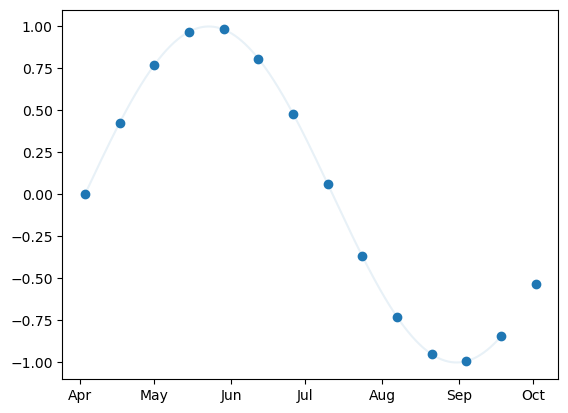

In [ ]:

# Test what different periods would look like on this cadence 


period = 200 
start_date = dt.datetime(2026, 4, 3)

x_obs = np.arange(0, 28*7, 14)
y_obs = np.sin(2*np.pi* x_obs /period) 
dates_obs = [start_date + dt.timedelta(days=float(d)) for d in x_obs]

x_smooth = np.arange(0, 24*7, 0.01)
y_smooth = np.sin(2*np.pi* x_smooth /period) 
dates_smooth = [start_date + dt.timedelta(days=float(d)) for d in x_smooth]

plt.scatter(dates_obs, y_obs) 
plt.plot(dates_smooth, y_smooth, alpha=0.1) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))



Plot visibility of throughout year of a specified ra/dec coordinate 

Text(0.5, 1.0, 'Visibility of target (RA / dec = 10 00 00 -22 00 00)')

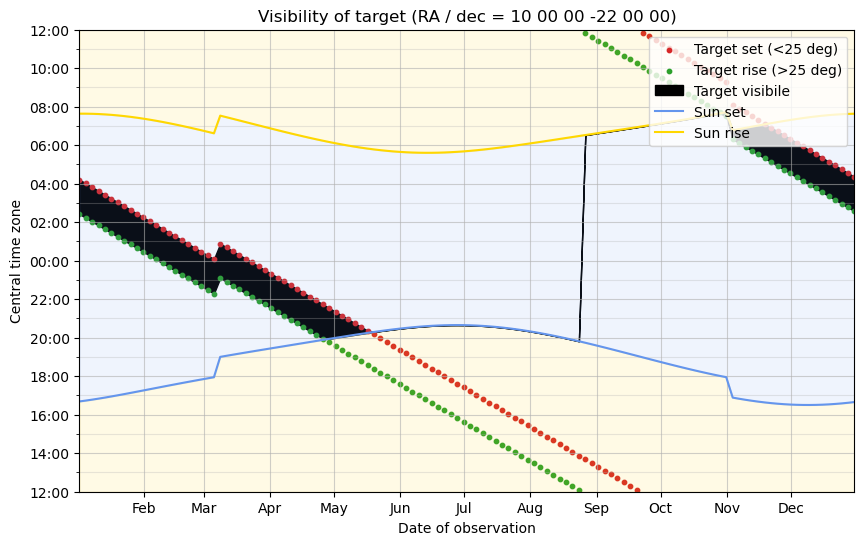

In [30]:
def get_observer(lat=41.66, lon=-91.53, height=200, tz="US/Central"):
    location = astropy.coordinates.EarthLocation(
        lat=lat*astropy.units.deg,
        lon=lon*astropy.units.deg,
        height=height*astropy.units.m)
    return astroplan.Observer(location=location, timezone=tz)





# Helper func 
def time_plottable_to_astroplan(time_plottable): 
    return astropy.time.Time(time_plottable.tz_convert('UTC').to_pydatetime())





# Calculate visiblity for a target 
def calc_visibility(Observer, Target, min_alt=25): 

    results = [] 
    dates = pd.date_range(
        start='2026-01-01 12:00:00',
        end='2026-12-31 12:00:00',
        freq='3D',
        tz='US/Central'
    )

    for date_plottable in dates: 

        # Date of observation 
        date_astroplan = time_plottable_to_astroplan(date_plottable)

        # Target/sun rise/set times (astroplan)
        target_rise_time_astroplan = Observer.target_rise_time(date_astroplan, Target, which='next', horizon=min_alt*astropy.units.deg)
        target_set_time_astroplan = Observer.target_set_time(date_astroplan, Target, which='next', horizon=min_alt*astropy.units.deg)
        sun_rise_time_astroplan = Observer.sun_rise_time(date_astroplan, which='next')
        sun_set_time_astroplan = Observer.sun_set_time(date_astroplan, which='next')

        # Express all times as time since noon today 
        target_rise_relative = target_rise_time_astroplan - date_astroplan 
        target_set_relative = target_set_time_astroplan - date_astroplan 
        sun_rise_relative = sun_rise_time_astroplan - date_astroplan 
        sun_set_relative = sun_set_time_astroplan - date_astroplan 

        # Currently visible 
        if target_set_time_astroplan<target_rise_time_astroplan: 

            # Sets before sunset 
            if target_set_time_astroplan<sun_set_time_astroplan: 

                if target_rise_time_astroplan<sun_set_time_astroplan: 
                    start=sun_set_time_astroplan 
                    end=sun_rise_time_astroplan 
                if sun_set_time_astroplan<target_rise_time_astroplan<sun_rise_time_astroplan: 
                    start=target_rise_time_astroplan 
                    end=sun_rise_time_astroplan 
                if target_rise_time_astroplan>sun_rise_time_astroplan: 
                    start=sun_rise_time_astroplan 
                    end=sun_rise_time_astroplan 
                
            # Sets during the night 
            if sun_set_time_astroplan<target_set_time_astroplan<sun_rise_time_astroplan: 
                start=sun_set_time_astroplan 
                end=target_set_time_astroplan 
            
            # Sets after sunrise 
            if target_set_time_astroplan>sun_rise_time_astroplan: 
                start=sun_set_time_astroplan 
                end=sun_rise_time_astroplan 

        # Currently not visible 
        if target_set_time_astroplan>target_rise_time_astroplan: 

            # Rises before sunset 
            if target_rise_time_astroplan<sun_set_time_astroplan: 

                if target_set_time_astroplan<sun_set_time_astroplan: 
                    start=sun_set_time_astroplan 
                    end=sun_set_time_astroplan 
                if sun_set_time_astroplan<target_set_time_astroplan<sun_rise_time_astroplan: 
                    start=sun_set_time_astroplan 
                    end=target_set_time_astroplan 
                if target_set_time_astroplan>sun_rise_time_astroplan: 
                    start=sun_set_time_astroplan 
                    end=sun_rise_time_astroplan 

            # Rises during the night 
            if sun_set_time_astroplan<target_rise_time_astroplan<sun_rise_time_astroplan: 

                if target_set_time_astroplan<sun_rise_time_astroplan: 
                    start=target_rise_time_astroplan 
                    end=target_set_time_astroplan 
                if target_set_time_astroplan>sun_rise_time_astroplan: 
                    start=target_rise_time_astroplan
                    end=sun_rise_time_astroplan
            
            # Rises after sunrise 
            if target_rise_time_astroplan>sun_rise_time_astroplan: 
                start = sun_rise_time_astroplan  
                end = sun_rise_time_astroplan 

        try: 
            start_relative = start - date_astroplan 
            end_relative = end - date_astroplan 
        except: 
            # If target is always up, use sunrise and sunset as start/end times 
            if Target.dec >= 0: 
                start_relative = sun_set_relative 
                end_relative = sun_rise_relative 
            # If target is never up, use sunrise as both to show its never up? 
            if Target.dec < 0: 
                start_relative = sun_rise_relative 
                end_relative = sun_rise_relative 

        # Save results as a dictionary 
        results.append({
            "target_rise_relative": target_rise_relative, 
            "target_set_relative": target_set_relative, 
            "sun_rise_relative": sun_rise_relative, 
            "sun_set_relative": sun_set_relative, 
            "start_relative": start_relative, 
            "end_relative": end_relative, 
        })

    return dates, results 




def plot_visibility(dates, results, min_alt=25): 

    fig, ax = plt.subplots(figsize=(10,6)) 

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) 
    ax.set_xlabel("Date of observation") 
    ax.set_xlim(dates[0], dates[-1]) 
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
    
    ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=pytz.timezone("US/Central"))) 
    ax.set_ylabel("Central time zone") 
    ax.set_ylim(dates[0], dates[0]+pd.Timedelta(days=1))
    ax.yaxis.set_major_locator(mdates.HourLocator(interval=2)) 
    ax.yaxis.set_minor_locator(mdates.HourLocator(interval=1)) 
    
    ax.grid(alpha=0.6, which="major")
    ax.grid(alpha=0.3, which="minor")

    def get_time(string): 
        return [pd.Timestamp((x[string] + time_plottable_to_astroplan(dates[0])).to_datetime()).tz_localize("UTC").tz_convert("US/Central") for x in results]

    # Target rise/set time 
    try: 
        ax.scatter(dates, get_time("target_set_relative"), color="tab:red", s=10, label=f"Target set (<{min_alt} deg)")
        ax.scatter(dates, get_time("target_rise_relative"), color="tab:green", s=10, label=f"Target rise (>{min_alt} deg)")
    except: 
        pass 

    # Highlight period that target is observable 
    ax.fill_between(dates, get_time("start_relative"), get_time("end_relative"), color="black", zorder=0, label="Target visibile") 

    # Sun rise/set times 
    ax.plot(dates, get_time("sun_set_relative"), color="cornflowerblue", label="Sun set")
    ax.plot(dates, get_time("sun_rise_relative"), color="gold", label="Sun rise")

    # Day vs night background colors 
    ax.fill_between(dates, dates[0], get_time("sun_set_relative"), color="gold", alpha=0.1)
    ax.fill_between(dates, get_time("sun_set_relative"), get_time("sun_rise_relative"), color="cornflowerblue", alpha=0.1)
    ax.fill_between(dates, get_time("sun_rise_relative"), dates[0]+pd.Timedelta(days=1), color="gold", alpha=0.1)

    ax.legend(loc="upper right") 




# Test code on various ra/dec positions 
cassiopeia = '23 30 00 +60 00 00'
gemini = "7 00 00 +20 00 00"
ursa_minor = "0 00 00 +80 00 00" 
aquarius = "21 00 00 -10 00 00"
antlia = "10 00 00 -30 00 00"
hydra = "10 00 00 -22 00 00"



ra_dec_str = hydra 

Observer = get_observer() 
Target = astroplan.FixedTarget(coord=astropy.coordinates.SkyCoord(ra_dec_str, unit=(astropy.units.hourangle, astropy.units.deg)) ) 
dates, results = calc_visibility(Observer, Target)
plot_visibility(dates, results)
plt.title(f"Visibility of target (RA / dec = {ra_dec_str})")




